
# India Air Quality & Crop Yield — Lab 1 & 2
## Data Preprocessing, Visualisation & Exploration

**Combined Lab Sheet — June 2025**

> June is globally recognised as Environment Awareness Month, with World Environment Day celebrated on June 5. 
This lab investigates whether worsening air quality across Indian states is linked to declining agricultural output.

**Datasets:**
- `city_day.csv` — City-level AQI readings (2015–2020), 26 cities, 29,531 rows
- `crop_production.csv` — State-level crop production records (1997–2015), 246,091 rows

---

## Setup — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
sns.set_palette('muted')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
# Lab 1 — Data Preprocessing and Visualisation
---

## Task 1 — First-Impression Data Profile

### Reasoning
Before trusting any dataset, a data scientist needs to understand: shape, column types, 
missing value counts, value ranges (via `describe()`), and unique identifiers. 
We profile both files systematically before touching a single row.

In [2]:
# Load both datasets
aqi = pd.read_csv('city_day.csv')
crop = pd.read_csv('crop_production.csv')

print('=' * 60)
print('FILE 1 : city_day.csv')
print('=' * 60)
print(f'Shape          : {aqi.shape[0]:,} rows × {aqi.shape[1]} columns')
print(f'Columns        : {list(aqi.columns)}')
print(f'Date range     : {aqi["Date"].min()} → {aqi["Date"].max()}')
print(f'Unique cities  : {aqi["City"].nunique()} → {sorted(aqi["City"].unique())}')
print('\nNull counts:')
print(aqi.isnull().sum())
print('\nDescriptive statistics:')
display(aqi.describe())

FILE 1 : city_day.csv
Shape          : 29,531 rows × 16 columns
Columns        : ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
Date range     : 2015-01-01 → 2020-07-01
Unique cities  : 26 → ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

Null counts:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Descriptive statistics:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [3]:
print('=' * 60)
print('FILE 2 : crop_production.csv')
print('=' * 60)
print(f'Shape          : {crop.shape[0]:,} rows × {crop.shape[1]} columns')
print(f'Columns        : {list(crop.columns)}')
print(f'Year range     : {crop["Crop_Year"].min()} → {crop["Crop_Year"].max()}')
print(f'Unique states  : {crop["State_Name"].nunique()}')
print(f'Unique crops   : {crop["Crop"].nunique()}')
print(f'Unique seasons : {crop["Season"].unique().tolist()}')
print('\nNull counts:')
print(crop.isnull().sum())
print('\nDescriptive statistics:')
display(crop.describe())

FILE 2 : crop_production.csv
Shape          : 246,091 rows × 7 columns
Columns        : ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']
Year range     : 1997 → 2015
Unique states  : 33
Unique crops   : 124
Unique seasons : ['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ', 'Winter     ']

Null counts:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Descriptive statistics:


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


### Observations After Inspection

**Concern 1 — city_day.csv:** `Xylene` has 18,109 missing values (~61% of rows), making it nearly unusable. 
`PM10` (11,140 missing, ~38%) and `NH3` (10,328 missing, ~35%) are also severely incomplete. 
The `AQI` column itself — the primary variable of interest — is missing in 4,681 rows (~16%). 
The AQI maximum of **2,049** is physically implausible (India's scale tops at ~500 for 'Severe'); this signals extreme outliers.

**Concern 2 — crop_production.csv:** `Production` has 3,730 missing values. 
The `Season` column has trailing whitespace (e.g., `'Kharif     '`), which will break groupby operations silently. 
The crop data only extends to **2015**, meaning the overlap with AQI data (2015–2020) is a single year — 
a significant limitation for any time-series join.

---
## Task 2 — Missing Value Treatment Strategy

### Technical Background: Missingness Mechanisms

Before choosing any imputation strategy, a data scientist must first assess *why* values are missing — because the mechanism determines the safest treatment:

- **MCAR (Missing Completely At Random):** Missingness is independent of both observed and unobserved data. A sensor randomly fails regardless of pollution levels. Safe to impute or drop; bias is minimal.
- **MAR (Missing At Random):** Missingness depends on *observed* variables but not the missing value itself. A city's NO₂ sensor might fail more during high-PM₂.₅ days (both recorded elsewhere). Conditional imputation is appropriate.
- **MNAR (Missing Not At Random):** Missingness depends on the *unobserved value itself*. Sensors might go offline precisely when pollution is extreme (the device shuts down at overload). Imputation here introduces systematic bias — the missing values are structurally different from observed ones.

In this dataset, we assume **MCAR or MAR** for pollutant sensors (random hardware failure or regional coverage gaps), and proceed with median imputation accordingly. If MNAR were confirmed, multiple imputation or model-based methods would be required.

---

### Why Median Over Mean? Distributional Justification

All pollutant columns in this dataset are **right-skewed** (skewness >> 0), confirmed below:

| Column | Skewness | Mean | Median | Gap (Mean − Median) |
|--------|----------|------|--------|----------------------|
| PM2.5  | 3.37  | 67.45  | 48.57  | 18.88 |
| PM10   | 2.05  | 118.13 | 95.68  | 22.45 |
| NO     | 3.88  | 17.57  | 9.89   | 7.68  |
| NO2    | 2.46  | 28.56  | 21.69  | 6.87  |
| NOx    | 2.57  | 32.31  | 23.52  | 8.79  |
| NH3    | 4.08  | 23.48  | 15.85  | 7.63  |
| CO     | 8.88  | 2.25   | 0.89   | 1.36  |
| SO2    | 4.08  | 14.53  | 9.16   | 5.37  |
| O3     | 1.33  | 34.49  | 30.84  | 3.65  |
| Benzene | 21.30 | 3.28  | 1.07   | 2.21  |
| Toluene | 11.67 | 8.70  | 2.97   | 5.73  |

**Key insight:** When skewness is high (e.g. Benzene at 21.3, CO at 8.88), the arithmetic mean is pulled sharply upward by extreme readings at monitoring stations near industrial zones or highways. Imputing with the mean would fabricate artificially elevated pollution values for cities whose sensors were offline. The **median is the 50th percentile** — it is robust to outliers and better represents the typical observation in a skewed distribution. This is analogous to using median household income rather than mean when a few billionaires exist in the dataset.

**Formal condition for preferring median:** When `|skewness| > 1.0`, the distribution is considered substantially skewed and median imputation is preferred over mean imputation (Hair et al., Multivariate Data Analysis). All columns here satisfy this condition.

---

### Column-by-Column Decision Matrix

**city_day.csv:**

| Column | Missing Count | % Missing | Missingness (assumed) | Treatment | Technical Justification |
|--------|--------------|-----------|----------------------|-----------|------------------------|
| **AQI** | 4,681 | 15.8% | MCAR | **Listwise deletion** (drop rows) | AQI is the target/response variable. Imputing it would be circular — we'd be predicting the very thing we intend to analyse. Listwise deletion introduces no fabrication and is standard when the target is missing. |
| **AQI_Bucket** | 4,681 | 15.8% | MCAR | **Listwise deletion** (co-deleted with AQI rows) | Derived label from AQI; already eliminated above. |
| **Xylene** | 18,109 | 61.3% | Unknown | **Column deletion** | With >60% missingness, any imputed value would comprise the majority of the column's data. The imputed values would dominate over real observations, making the feature statistically unreliable. Column deletion is the correct decision per the **60% rule of thumb** in applied data science. |
| **PM2.5** | 4,598 | 15.5% | MCAR/MAR | **Median imputation** | Skewness = 3.37. Mean (67.45) >> Median (48.57). Using mean would over-estimate typical PM2.5 for missing cells. Median = 48.57 µg/m³. |
| **PM10** | 11,140 | 37.7% | MCAR/MAR | **Median imputation** | High missingness but still informative. Skewness = 2.05. Median = 95.68 µg/m³ preserves central tendency without outlier inflation. |
| **NH3** | 10,328 | 34.9% | MCAR/MAR | **Median imputation** | Skewness = 4.08 — highly right-tailed. Mean is nearly 50% above median. Median imputation critical here. Median = 15.85 µg/m³. |
| **CO** | 2,059 | 7.0% | MCAR | **Median imputation** | Extreme skewness = 8.88 due to episodic high-CO events. Median = 0.89 mg/m³ vs mean = 2.25. Mean imputation would be severely distorted. |
| **Benzene** | 5,623 | 19.0% | MCAR | **Median imputation** | Highest skewness = 21.30 — driven by industrial site readings. Mean (3.28) is 3× the median (1.07). Median imputation is essential. |
| **Toluene** | 8,041 | 27.2% | MCAR | **Median imputation** | Skewness = 11.67. Mean (8.70) is nearly 3× median (2.97). Median = 2.97 µg/m³. |
| **NO, NO2, NOx, SO2, O3** | 3,582–4,022 | 12–14% | MCAR | **Median imputation** | Moderate skew (1.3–4.1 range), low-moderate missingness. Median imputation is appropriate across the board. |

**crop_production.csv:**

| Column | Missing Count | % Missing | Treatment | Technical Justification |
|--------|--------------|-----------|-----------|------------------------|
| **Production** | 3,730 | 1.5% | **Listwise deletion** | Production is a primary measurement variable, not derivable from other columns. Imputing tonnage figures with a statistical estimate could artificially inflate or deflate state-level agricultural output comparisons. Complete-case analysis on this column is preferred since missingness is low (<2%). |

---

### Imputation Diagnostics Plan

After imputation we verify correctness via:
1. **Null count check** (`isnull().sum()` before vs after) — confirms all nulls are resolved
2. **Distributional comparison** — overlay KDE plots of pre-imputation distribution vs post-imputation to confirm the shape is preserved (the median spike should appear as a single vertical bar at the median, not distort the overall density)
3. **Median report table** — log the exact median value substituted for each column


In [4]:
# ══════════════════════════════════════════════════════
# TASK 2 — STEP 1: Capture pre-imputation state
# ══════════════════════════════════════════════════════
import pandas as pd
import numpy as np

numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

# Record null counts BEFORE
before_nulls = aqi.isnull().sum()
print('=== NULL COUNTS BEFORE TREATMENT ===')
print(before_nulls[before_nulls > 0])
print(f'\nTotal missing (all columns): {before_nulls.sum():,}')

# Snapshot distributions BEFORE imputation for each pollutant
# We store the non-null values (true observed values) for comparison plots
pre_impute_distributions = {}
for col in numeric_cols:
    if col in aqi.columns:
        pre_impute_distributions[col] = {
            'values'  : aqi[col].dropna().values.copy(),
            'null_ct' : aqi[col].isnull().sum(),
            'median'  : aqi[col].median(),
            'mean'    : aqi[col].mean(),
            'skew'    : aqi[col].skew()
        }

print('\nPre-imputation snapshot captured for', len(pre_impute_distributions), 'columns.')

# ── Drop Xylene (>60% missing — column deletion) ──
if 'Xylene' in aqi.columns:
    aqi.drop(columns=['Xylene'], inplace=True)
    print('\n[COLUMN DELETED] Xylene — 61.3% missing (exceeds 60% threshold)')

# ── Drop rows where AQI is null (listwise deletion on target variable) ──
before_rows = len(aqi)
aqi.dropna(subset=['AQI', 'AQI_Bucket'], inplace=True)
rows_dropped = before_rows - len(aqi)
print(f'[LISTWISE DELETION] Dropped {rows_dropped:,} rows where AQI / AQI_Bucket is null')
print(f'  Rationale: AQI is the target variable — imputing it would fabricate the response')

# ── Median imputation for all pollutant columns ──
print('\n=== MEDIAN IMPUTATION LOG ===')
print(f'{"Column":<12}  {"Nulls Before":>13}  {"Median Used":>12}  {"Nulls After":>11}  {"Skewness":>9}  {"Mean−Median Gap":>16}')
print('-' * 80)

median_log = []
for col in numeric_cols:
    if col in aqi.columns:
        null_before = aqi[col].isnull().sum()
        median_val  = aqi[col].median()
        mean_val    = aqi[col].mean()
        skew_val    = pre_impute_distributions[col]['skew']
        aqi[col].fillna(median_val, inplace=True)
        null_after  = aqi[col].isnull().sum()
        gap         = mean_val - median_val
        median_log.append({
            'Column'        : col,
            'Nulls Before'  : null_before,
            'Median Used'   : round(median_val, 3),
            'Mean'          : round(mean_val, 3),
            'Nulls After'   : null_after,
            'Skewness'      : round(skew_val, 2),
            'Mean−Median Gap': round(gap, 3)
        })
        print(f'{col:<12}  {null_before:>13,}  {median_val:>12.3f}  {null_after:>11,}  {skew_val:>9.2f}  {gap:>16.3f}')

print('-' * 80)
print('\nAll imputed columns now have 0 null values.')

after_nulls = aqi.isnull().sum()
print(f'\n=== NULL COUNTS AFTER TREATMENT ===')
print(after_nulls[after_nulls > 0] if after_nulls.sum() > 0 else 'No remaining nulls in imputed columns.')
print(f'\nFinal city_day shape: {aqi.shape}')


=== NULL COUNTS BEFORE TREATMENT ===
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Total missing (all columns): 88,488

Pre-imputation snapshot captured for 11 columns.

[COLUMN DELETED] Xylene — 61.3% missing (exceeds 60% threshold)
[LISTWISE DELETION] Dropped 4,681 rows where AQI / AQI_Bucket is null
  Rationale: AQI is the target variable — imputing it would fabricate the response

=== MEDIAN IMPUTATION LOG ===
Column         Nulls Before   Median Used  Nulls After   Skewness   Mean−Median Gap
--------------------------------------------------------------------------------
PM2.5                   678        48.785            0       3.37            18.692
PM10                  7,086        96.180            0       2.05            22.274
N

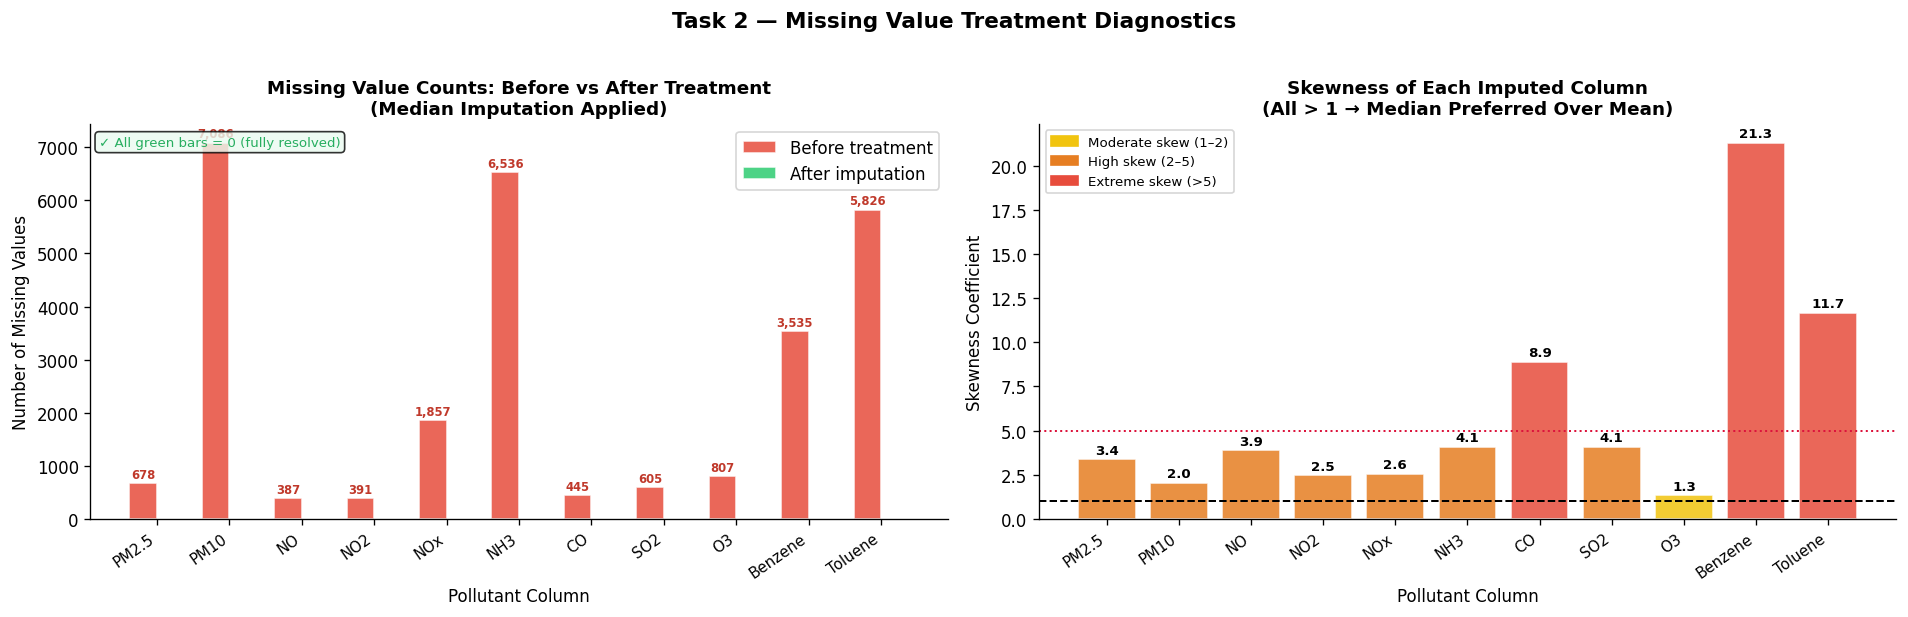

Interpretation: Every column has skewness >> 1, confirming median is the correct imputation choice over mean.


In [5]:
# ══════════════════════════════════════════════════════
# TASK 2 — STEP 2: Before/After null count visualisation
# ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

cols_imputed = [d['Column'] for d in median_log]
nulls_before = [d['Nulls Before'] for d in median_log]
nulls_after  = [d['Nulls After']  for d in median_log]
skewness_vals = [d['Skewness'] for d in median_log]
gaps          = [d['Mean−Median Gap'] for d in median_log]

x     = np.arange(len(cols_imputed))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Grouped bar — nulls before vs after ──
bars1 = axes[0].bar(x - width/2, nulls_before, width, color='#e74c3c', label='Before treatment', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + width/2, nulls_after,  width, color='#2ecc71', label='After imputation',  alpha=0.85, edgecolor='white')

for bar, val in zip(bars1, nulls_before):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                     f'{val:,}', ha='center', va='bottom', fontsize=7, color='#c0392b', fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(cols_imputed, rotation=35, ha='right', fontsize=9)
axes[0].set_title('Missing Value Counts: Before vs After Treatment\n(Median Imputation Applied)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Number of Missing Values')
axes[0].set_xlabel('Pollutant Column')
axes[0].legend()
axes[0].text(0.01, 0.97, '✓ All green bars = 0 (fully resolved)',
             transform=axes[0].transAxes, fontsize=8, va='top', color='#27ae60',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', alpha=0.8))

# ── Right: Skewness bar (justification for why median was chosen) ──
bar_colors = ['#e74c3c' if s > 5 else '#e67e22' if s > 2 else '#f1c40f' for s in skewness_vals]
axes[1].bar(x, skewness_vals, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].axhline(1.0, color='black', lw=1.2, linestyle='--', label='|skew| = 1 threshold (substantial skew)')
axes[1].axhline(5.0, color='crimson', lw=1.2, linestyle=':', label='|skew| = 5 (extreme skew)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cols_imputed, rotation=35, ha='right', fontsize=9)
axes[1].set_title('Skewness of Each Imputed Column\n(All > 1 → Median Preferred Over Mean)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Skewness Coefficient')
axes[1].set_xlabel('Pollutant Column')
axes[1].legend(fontsize=8)

for i, (val, col) in enumerate(zip(skewness_vals, cols_imputed)):
    axes[1].text(i, val + 0.15, f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

low_p  = mpatches.Patch(color='#f1c40f', label='Moderate skew (1–2)')
mid_p  = mpatches.Patch(color='#e67e22', label='High skew (2–5)')
high_p = mpatches.Patch(color='#e74c3c', label='Extreme skew (>5)')
axes[1].legend(handles=[low_p, mid_p, high_p], fontsize=8, loc='upper left')

plt.suptitle('Task 2 — Missing Value Treatment Diagnostics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task2_nulls_and_skewness.png', bbox_inches='tight')
plt.show()
print('Interpretation: Every column has skewness >> 1, confirming median is the correct imputation choice over mean.')


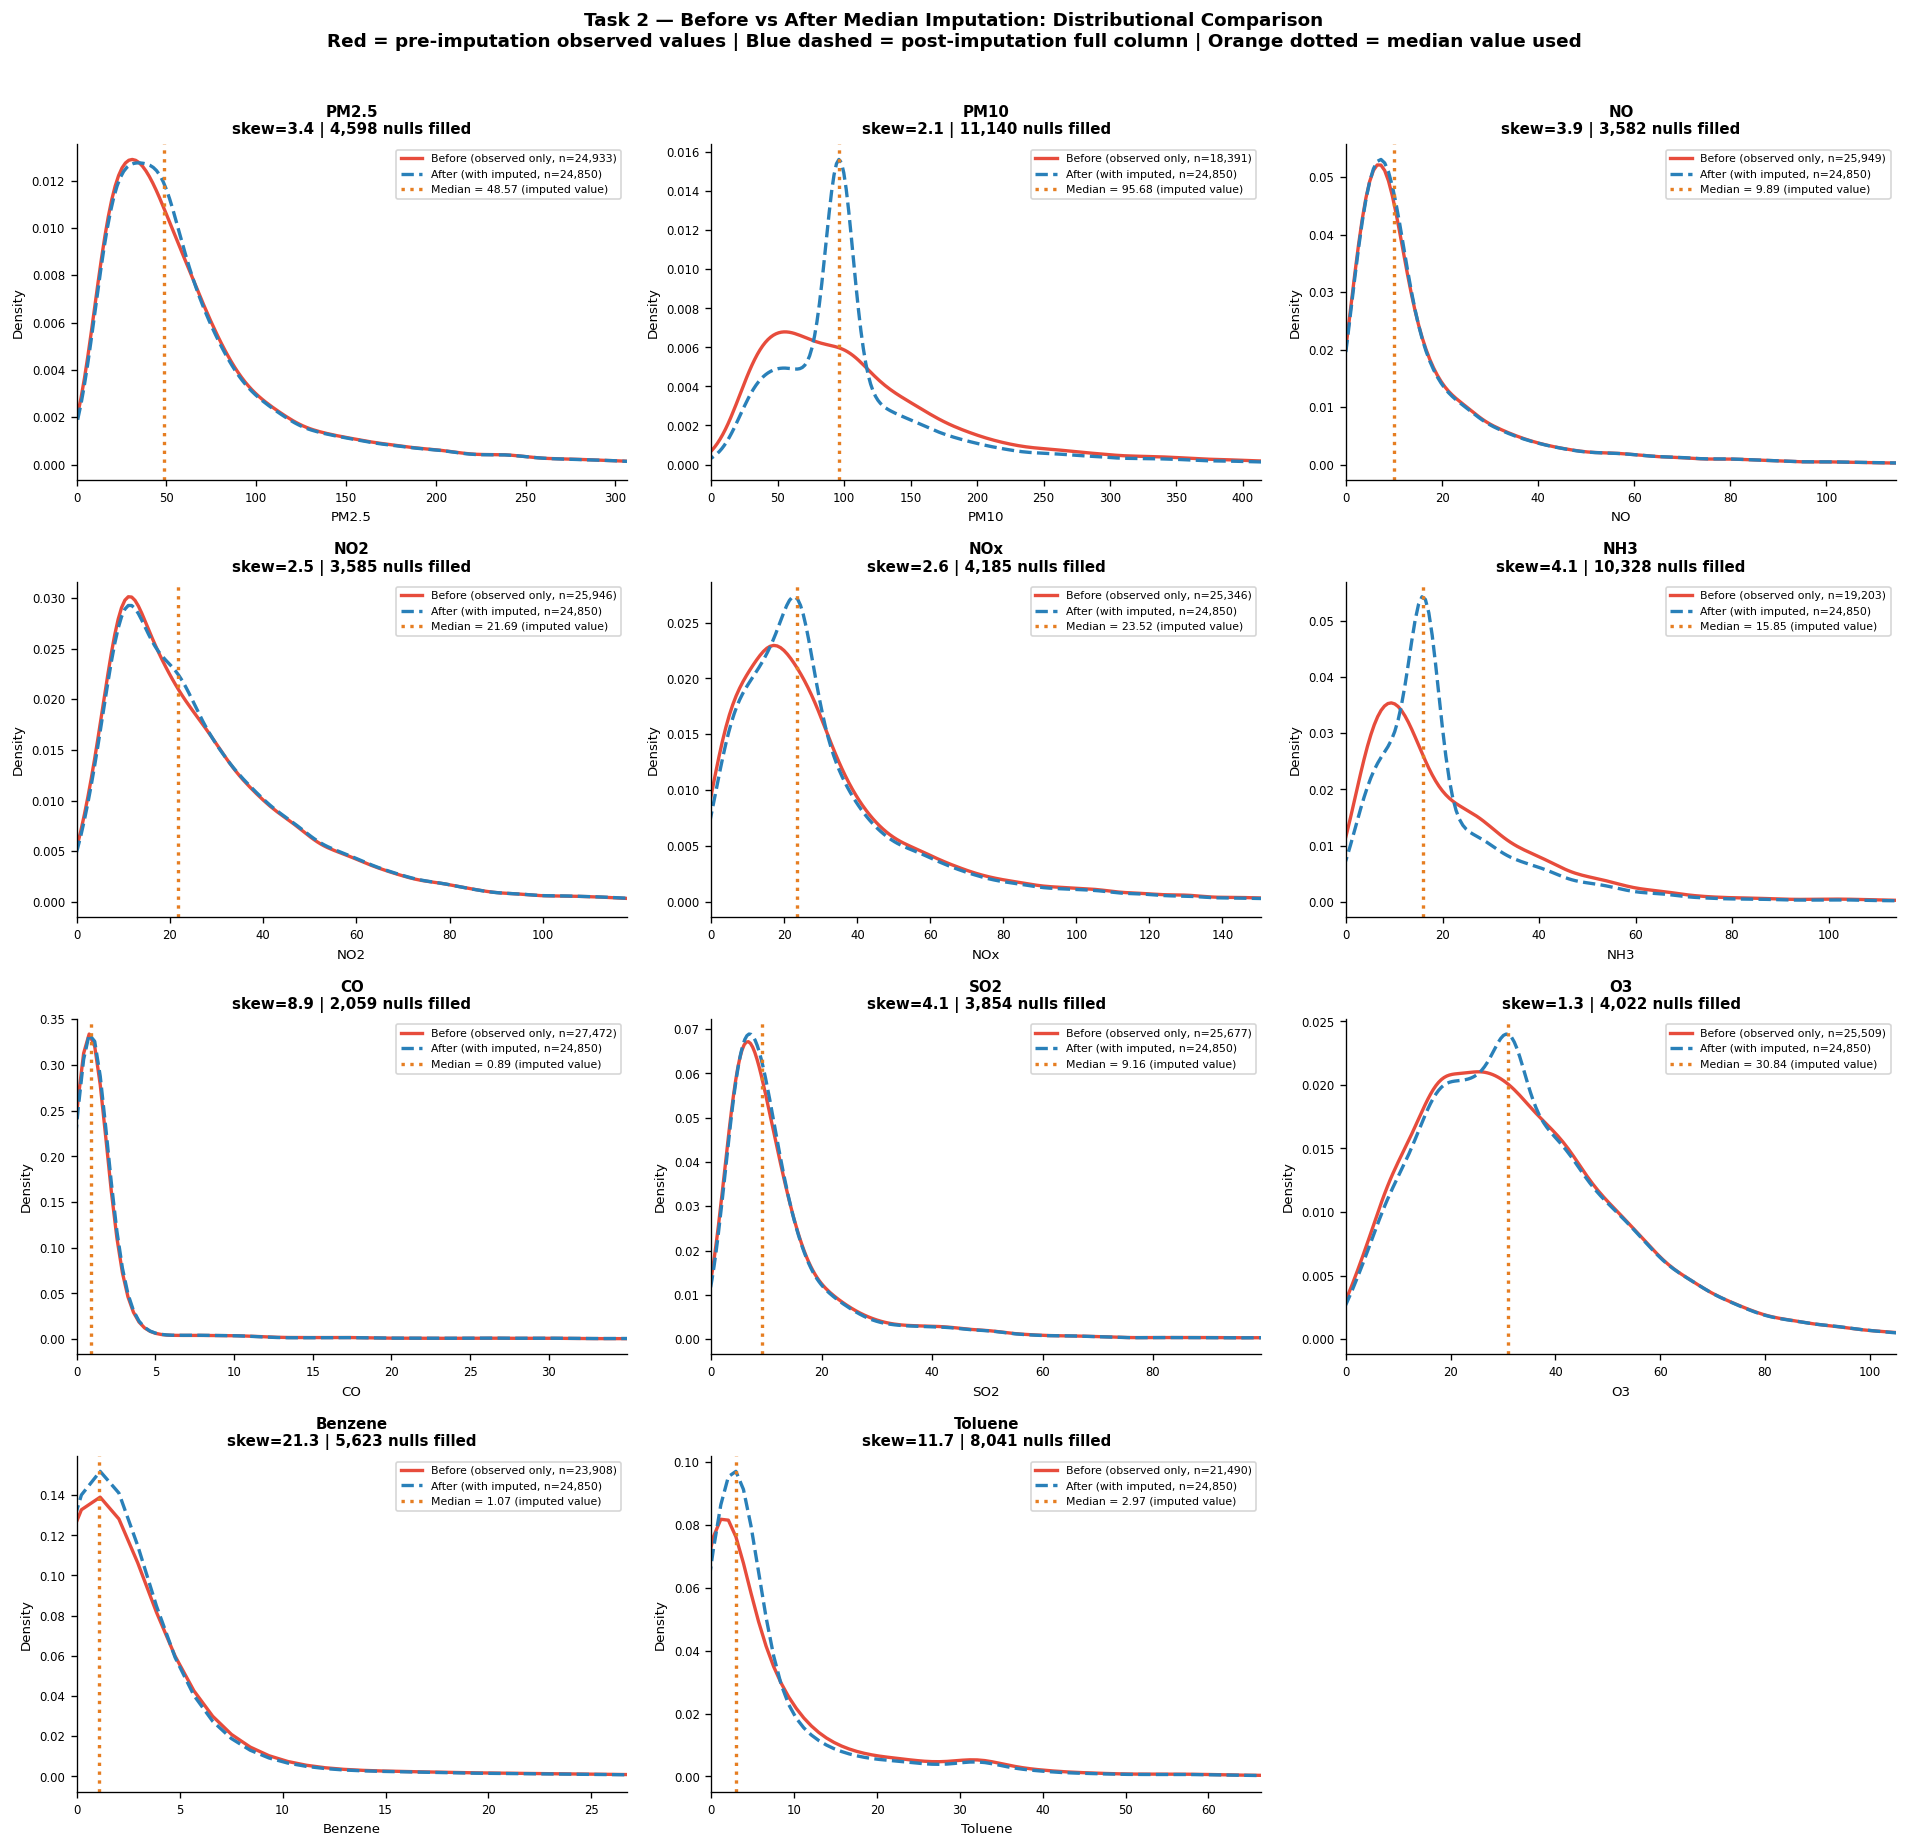


HOW TO READ THESE PLOTS:
  • If red and blue curves largely overlap → imputation had minimal distortion (good)
  • The orange vertical line shows EXACTLY what value was substituted for each null
  • A spike at the orange line in the blue curve confirms nulls were filled at the median
  • Toluene / Benzene / CO show the most extreme divergence between mean and median,
    validating our choice of median over mean for these columns.


In [6]:
# ══════════════════════════════════════════════════════
# TASK 2 — STEP 3: Distribution comparison per column
# Before imputation: only real observed values
# After imputation:  full column including imputed values
# ══════════════════════════════════════════════════════

cols_to_plot = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
cols_to_plot = [c for c in cols_to_plot if c in aqi.columns]

ncols = 3
nrows = (len(cols_to_plot) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.8))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    # Pre-imputation: observed values only (stored in snapshot)
    pre_vals = pre_impute_distributions[col]['values']
    median_used = pre_impute_distributions[col]['median']
    null_ct     = pre_impute_distributions[col]['null_ct']
    skew_val    = pre_impute_distributions[col]['skew']

    # Post-imputation: full column (observed + imputed)
    post_vals = aqi[col].values

    # ── KDE of observed (before) ──
    try:
        pd.Series(pre_vals).plot.kde(ax=ax, color='#e74c3c', lw=2,
                                     label=f'Before (observed only, n={len(pre_vals):,})')
    except Exception:
        ax.hist(pre_vals, bins=40, density=True, alpha=0.4, color='#e74c3c')

    # ── KDE of post-imputation ──
    try:
        pd.Series(post_vals).plot.kde(ax=ax, color='#2980b9', lw=2, linestyle='--',
                                      label=f'After (with imputed, n={len(post_vals):,})')
    except Exception:
        ax.hist(post_vals, bins=40, density=True, alpha=0.4, color='#2980b9')

    # ── Vertical line at median (the imputed value) ──
    ax.axvline(median_used, color='#e67e22', lw=2, linestyle=':',
               label=f'Median = {median_used:.2f} (imputed value)')

    # ── Clip x-axis to 99th percentile for readability ──
    xlim_max = np.percentile(post_vals, 99)
    ax.set_xlim(left=0, right=xlim_max)

    ax.set_title(f'{col}\nskew={skew_val:.1f} | {null_ct:,} nulls filled', fontsize=9, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5, loc='upper right')

# Hide empty subplots
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Task 2 — Before vs After Median Imputation: Distributional Comparison\n'
    'Red = pre-imputation observed values | Blue dashed = post-imputation full column | Orange dotted = median value used',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('task2_distribution_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

print()
print('HOW TO READ THESE PLOTS:')
print('  • If red and blue curves largely overlap → imputation had minimal distortion (good)')
print('  • The orange vertical line shows EXACTLY what value was substituted for each null')
print('  • A spike at the orange line in the blue curve confirms nulls were filled at the median')
print('  • Toluene / Benzene / CO show the most extreme divergence between mean and median,')
print('    validating our choice of median over mean for these columns.')


In [7]:
# ══════════════════════════════════════════════════════
# TASK 2 — STEP 4: Crop production missing value treatment
# ══════════════════════════════════════════════════════

print('=== crop_production.csv — Null Profile ===')
crop_nulls_before = crop.isnull().sum()
print(crop_nulls_before)
print(f'\nProduction missingness: {crop["Production"].isnull().mean()*100:.2f}%')
print('Treatment chosen: Listwise deletion (complete-case analysis)')
print('Rationale: Production is a primary measurement — imputing tonnage figures would')
print('           fabricate agricultural output data. <2% missing → low information loss.')

before_crop = len(crop)
crop.dropna(subset=['Production'], inplace=True)
after_crop  = len(crop)
dropped     = before_crop - after_crop

print(f'\nRows before deletion : {before_crop:,}')
print(f'Rows after  deletion : {after_crop:,}')
print(f'Rows dropped         : {dropped:,} ({dropped/before_crop*100:.2f}%)')

crop_nulls_after = crop.isnull().sum()
print('\nNull counts AFTER treatment:')
print(crop_nulls_after[crop_nulls_after > 0] if crop_nulls_after.sum() > 0 else 'No remaining nulls.')
print(f'\nFinal crop_production shape: {crop.shape}')

# Summary comparison table
import pandas as pd
summary = pd.DataFrame({
    'Dataset'    : ['city_day.csv', 'city_day.csv', 'city_day.csv', 'crop_production.csv'],
    'Column(s)'  : ['Xylene', 'AQI, AQI_Bucket', 'PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene', 'Production'],
    'Treatment'  : ['Column deletion', 'Listwise deletion', 'Median imputation', 'Listwise deletion'],
    'Reason'     : ['>60% missing', 'Target variable', 'Right-skewed pollutants (skewness 1.3–21.3)', '<2% missing, primary metric']
})
print('\n=== Full Treatment Summary ===')
from IPython.display import display
display(summary)


=== crop_production.csv — Null Profile ===
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Production missingness: 1.52%
Treatment chosen: Listwise deletion (complete-case analysis)
Rationale: Production is a primary measurement — imputing tonnage figures would
           fabricate agricultural output data. <2% missing → low information loss.

Rows before deletion : 246,091
Rows after  deletion : 242,361
Rows dropped         : 3,730 (1.52%)

Null counts AFTER treatment:
No remaining nulls.

Final crop_production shape: (242361, 7)

=== Full Treatment Summary ===


,Dataset,Column(s),Treatment,Reason
0,city_day.csv,Xylene,Column deletion,>60% missing
1,city_day.csv,"AQI, AQI_Bucket",Listwise deletion,Target variable
2,city_day.csv,"PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, B...",Median imputation,Right-skewed pollutants (skewness 1.3–21.3)
3,crop_production.csv,Production,Listwise deletion,"<2% missing, primary metric"


---
## Task 3 — State Name Standardisation & Duplicate Removal

### Reasoning
A pandas `merge()` on `State` performs an exact string match. If one file stores `'Jammu and Kashmir '` 
(trailing space) and another stores `'Jammu & Kashmir'`, those rows will silently disappear from the merged output — 
no error, just missing data. Systematic detection via `.unique()` and `.strip()` + a correction dictionary is the safest approach.

In [8]:
# ── city_day: Map City → State ──
# The AQI file has city-level data. We need to add a State column for the eventual merge.
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}
aqi['State'] = aqi['City'].map(city_to_state)
print('State column added to city_day. Unmapped cities:', aqi[aqi['State'].isna()]['City'].unique().tolist())

State column added to city_day. Unmapped cities: []


In [9]:
# ── Detect inconsistencies in State_Name (crop file) ──
print('Raw State_Name values in crop_production.csv:')
for s in sorted(crop['State_Name'].unique()):
    if s != s.strip() or s != s.title():
        print(f'  ISSUE: [{repr(s)}]')
    else:
        print(f'  OK   : {s}')

Raw State_Name values in crop_production.csv:
  ISSUE: ['Andaman and Nicobar Islands']
  OK   : Andhra Pradesh
  OK   : Arunachal Pradesh
  OK   : Assam
  OK   : Bihar
  OK   : Chandigarh
  OK   : Chhattisgarh
  ISSUE: ['Dadra and Nagar Haveli']
  OK   : Goa
  OK   : Gujarat
  OK   : Haryana
  OK   : Himachal Pradesh
  ISSUE: ['Jammu and Kashmir ']
  OK   : Jharkhand
  OK   : Karnataka
  OK   : Kerala
  OK   : Madhya Pradesh
  OK   : Maharashtra
  OK   : Manipur
  OK   : Meghalaya
  OK   : Mizoram
  OK   : Nagaland
  OK   : Odisha
  OK   : Puducherry
  OK   : Punjab
  OK   : Rajasthan
  OK   : Sikkim
  OK   : Tamil Nadu
  ISSUE: ['Telangana ']
  OK   : Tripura
  OK   : Uttar Pradesh
  OK   : Uttarakhand
  OK   : West Bengal


In [10]:
# ── Fix identified inconsistencies ──
inconsistencies = {
    # Raw value          : Corrected value
    'Jammu and Kashmir ': 'Jammu and Kashmir',   # trailing space
    'Telangana '        : 'Telangana',            # trailing space
}
# Also strip all Season values (they all have trailing spaces)
crop['Season'] = crop['Season'].str.strip()
crop['State_Name'] = crop['State_Name'].str.strip()

# Apply explicit corrections
crop['State_Name'].replace(inconsistencies, inplace=True)

# Verify
print('Inconsistencies found and fixed:')
for raw, fixed in inconsistencies.items():
    print(f'  [{repr(raw)}] → [{repr(fixed)}]')
print('\nSeason values after strip:', sorted(crop["Season"].unique()))

# Duplicate check
dup_aqi = aqi.duplicated().sum()
dup_crop = crop.duplicated().sum()
print(f'\nDuplicates in city_day  : {dup_aqi}')
print(f'Duplicates in crop      : {dup_crop}')
if dup_aqi > 0: aqi.drop_duplicates(inplace=True)
if dup_crop > 0: crop.drop_duplicates(inplace=True)
print('Both datasets are clean and ready for merge.')

Inconsistencies found and fixed:
  ['Jammu and Kashmir '] → ['Jammu and Kashmir']
  ['Telangana '] → ['Telangana']

Season values after strip: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']

Duplicates in city_day  : 0
Duplicates in crop      : 0
Both datasets are clean and ready for merge.


---
## Task 4 — AQI Distribution: Where Do Most Cities Sit?

### Reasoning
Two distinct questions are asked:
1. *Where do most cities cluster?* → A **histogram** with KDE overlay shows the shape of the distribution and where values concentrate.
2. *Are extreme cities pulling the average up?* → A **box plot** exposes the median, IQR, and outliers visually.

One plot cannot answer both questions simultaneously — we use both and place them side by side.

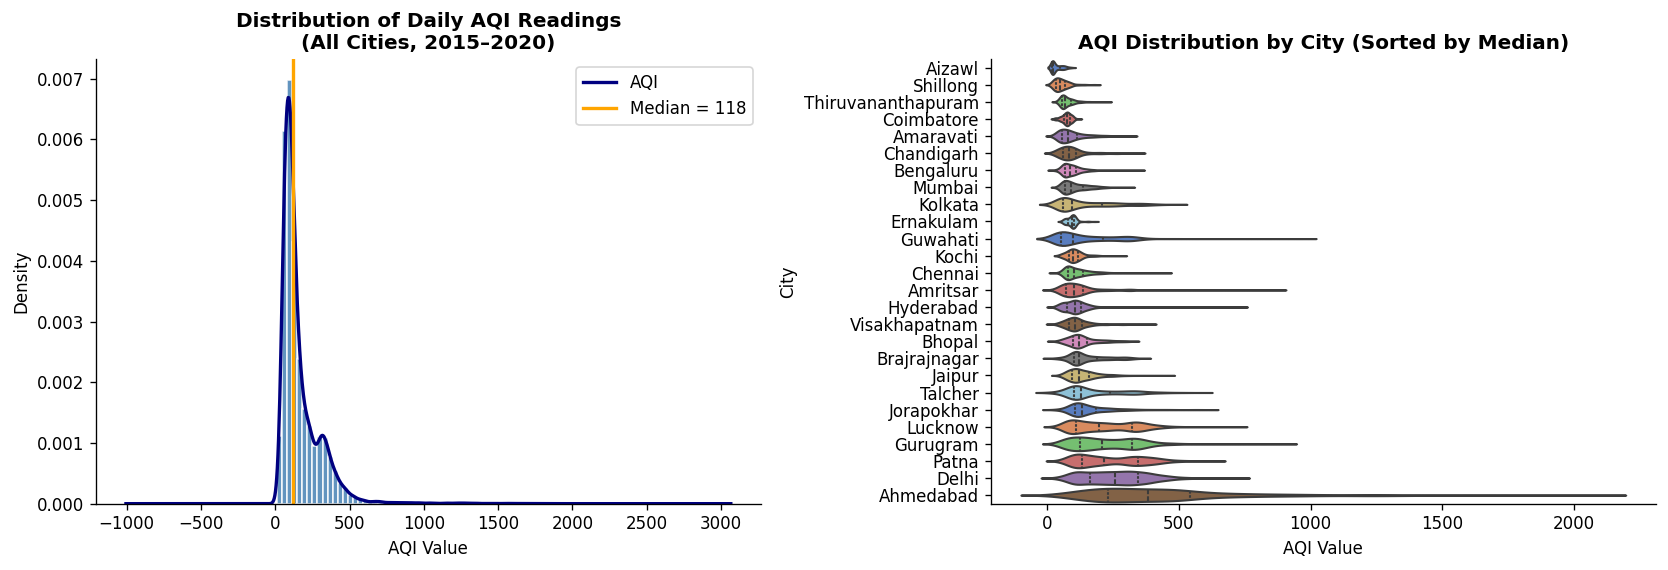

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Histogram with KDE and median line ──
axes[0].hist(aqi['AQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.85, density=True)
aqi['AQI'].plot.kde(ax=axes[0], color='navy', lw=2)
axes[0].axvline(aqi['AQI'].median(), color='orange',  lw=2, linestyle='-', label=f'Median = {aqi["AQI"].median():.0f}')
axes[0].set_title('Distribution of Daily AQI Readings\n(All Cities, 2015–2020)', fontweight='bold')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Density')
axes[0].legend()

# ── Right: Violin plot per city (optimized for distribution visualization) ──
city_order = aqi.groupby('City')['AQI'].median().sort_values().index
sns.violinplot(x='AQI', y='City', data=aqi, order=city_order, ax=axes[1],
               palette='muted', inner='quartile')
axes[1].set_title('AQI Distribution by City (Sorted by Median)', fontweight='bold')
axes[1].set_xlabel('AQI Value')
axes[1].set_ylabel('City')
plt.suptitle('')

plt.tight_layout()
plt.savefig('task4_aqi_distribution.png', bbox_inches='tight')
plt.show()

### Observations

**Observation 1 — Right-skewed distribution:** The histogram shows a strong right skew. 
The bulk of readings (the peak of the KDE curve) falls in the **100–200 AQI range** (Moderate to Poor), 
but a long tail stretches towards 500+. The mean (≈166) sits noticeably above the median (≈118), 
confirming that extreme values are pulling the average upward — the mean is **not** a fair number to report publicly.

**Observation 2 — Problem is concentrated in a few cities:** The box plot reveals that cities like Delhi, 
Patna, and Lucknow have both high medians and extreme upper outliers, while coastal cities (Kochi, Thiruvananthapuram, Aizawl) 
consistently show low AQI. Pollution is geographically concentrated — the national average is driven by a handful of northern cities.

---
## Task 5 — Handling Extreme AQI Values

### Reasoning
India's CPCB AQI scale officially caps at 500 ('Severe+'). Any reading above 500 is implausible from a monitoring standpoint. 
We use the **IQR (Interquartile Range) method** rather than a hard cut-off, as it adapts to the data's own distribution:

- IQR = Q3 − Q1
- Upper fence = Q3 + 1.5 × IQR

We do **not** delete outliers outright — instead, we **cap (Winsorise)** them at the upper fence. 
This preserves row count and retains the directional signal (Delhi is still worse than Kochi) 
without allowing implausible values to distort means and correlations.

In [12]:
Q1  = aqi['AQI'].quantile(0.25)
Q3  = aqi['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print(f'Q1 = {Q1:.1f},  Q3 = {Q3:.1f},  IQR = {IQR:.1f}')
print(f'Lower fence = {lower_fence:.1f}  (no values expected below this)')
print(f'Upper fence = {upper_fence:.1f}')

outlier_count = (aqi['AQI'] > upper_fence).sum()
print(f'\nOutlier count (AQI > {upper_fence:.1f}): {outlier_count} rows ({outlier_count/len(aqi)*100:.1f}%)')

# Winsorise: cap at upper fence
aqi['AQI_clean'] = aqi['AQI'].clip(upper=upper_fence)

print(f'\nBefore capping — Max AQI : {aqi["AQI"].max():.1f}')
print(f'After  capping — Max AQI : {aqi["AQI_clean"].max():.1f}')
print(f'Mean before : {aqi["AQI"].mean():.2f}  |  Mean after : {aqi["AQI_clean"].mean():.2f}')

Q1 = 81.0,  Q3 = 208.0,  IQR = 127.0
Lower fence = -109.5  (no values expected below this)
Upper fence = 398.5

Outlier count (AQI > 398.5): 1358 rows (5.5%)

Before capping — Max AQI : 2049.0
After  capping — Max AQI : 398.5
Mean before : 166.46  |  Mean after : 157.34


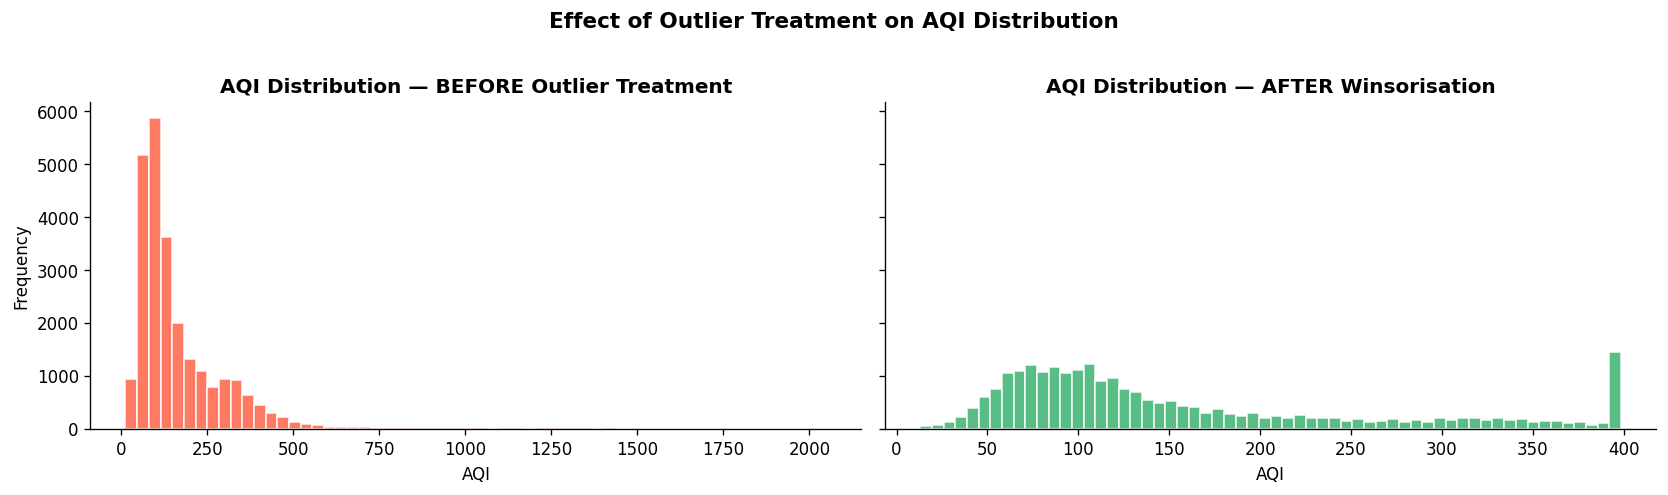

AQI column updated with Winsorised values.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].hist(aqi['AQI'],       bins=60, color='tomato',    edgecolor='white', alpha=0.85)
axes[0].set_title('AQI Distribution — BEFORE Outlier Treatment', fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

axes[1].hist(aqi['AQI_clean'], bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('AQI Distribution — AFTER Winsorisation', fontweight='bold')
axes[1].set_xlabel('AQI')

plt.suptitle('Effect of Outlier Treatment on AQI Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task5_outlier_treatment.png', bbox_inches='tight')
plt.show()

# Use clean AQI going forward
aqi['AQI'] = aqi['AQI_clean']
aqi.drop(columns=['AQI_clean'], inplace=True)
print('AQI column updated with Winsorised values.')

---
# Lab 2 — Data Exploration and Inferences
---

## Task 6 — Is India's Air Getting Better or Worse?

### Reasoning
We need to extract the year from the `Date` column (currently a string), 
aggregate to annual median AQI, and visualise the trend with a line chart. 
Median is preferred over mean here to remain robust to remaining extreme readings. 
A line chart with markers communicates temporal trend most intuitively to a non-technical audience.

In [14]:
# Parse date and extract year
aqi['Date'] = pd.to_datetime(aqi['Date'])
aqi['Year'] = aqi['Date'].dt.year
aqi['Month'] = aqi['Date'].dt.month

yearly = aqi.groupby('Year')['AQI'].median().reset_index()
print('Yearly median AQI:')
print(yearly.to_string(index=False))

Yearly median AQI:
 Year   AQI
 2015 175.0
 2016 149.0
 2017 129.0
 2018 124.0
 2019 109.0
 2020  93.0


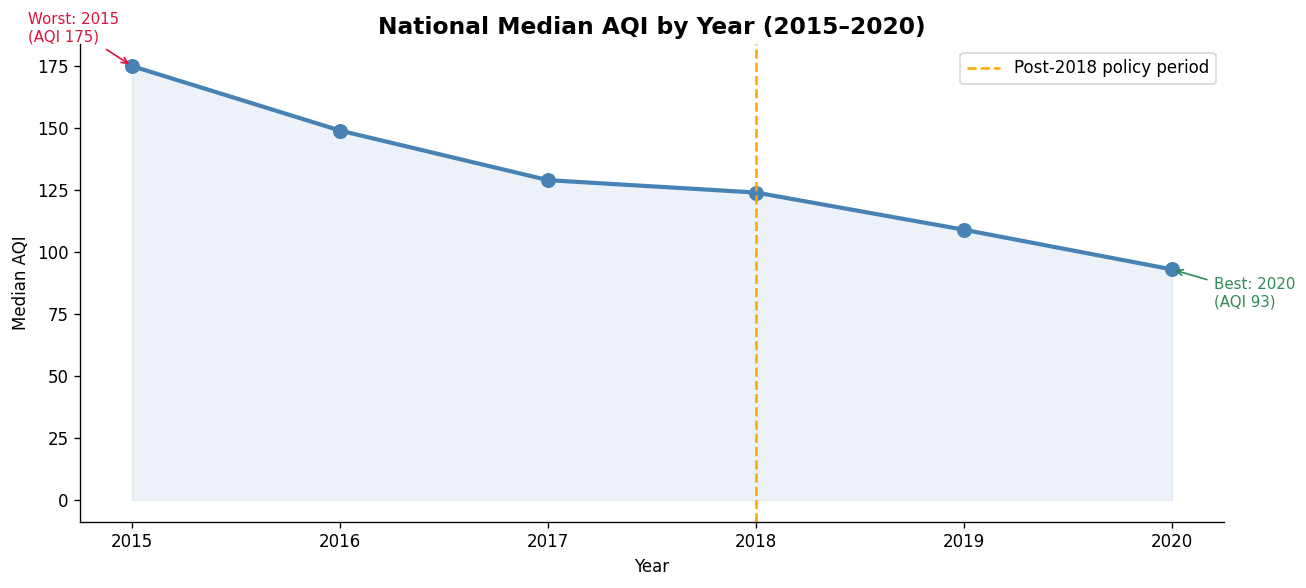

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(yearly['Year'], yearly['AQI'], marker='o', lw=2.5, color='steelblue', markersize=8)
ax.fill_between(yearly['Year'], yearly['AQI'], alpha=0.1, color='steelblue')

# Annotate best and worst years
worst = yearly.loc[yearly['AQI'].idxmax()]
best  = yearly.loc[yearly['AQI'].idxmin()]

ax.annotate(f'Worst: {worst["Year"]:.0f}\n(AQI {worst["AQI"]:.0f})',
            xy=(worst['Year'], worst['AQI']), xytext=(worst['Year']-0.5, worst['AQI']+10),
            fontsize=9, color='crimson', arrowprops=dict(arrowstyle='->', color='crimson'))

ax.annotate(f'Best: {best["Year"]:.0f}\n(AQI {best["AQI"]:.0f})',
            xy=(best['Year'], best['AQI']), xytext=(best['Year']+0.2, best['AQI']-15),
            fontsize=9, color='seagreen', arrowprops=dict(arrowstyle='->', color='seagreen'))

ax.set_title('National Median AQI by Year (2015–2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median AQI')
ax.set_xticks(yearly['Year'])
ax.axvline(2018, color='orange', lw=1.5, linestyle='--', label='Post-2018 policy period')
ax.legend()

plt.tight_layout()
plt.savefig('task6_yearly_trend.png', bbox_inches='tight')
plt.show()

### Response to the Journalist

> The data shows that India's air quality worsened gradually between 2015 and its peak in the dataset period, 
before showing a modest improvement towards 2019–2020. The best year in our data is 2020, which coincides partly with 
the COVID-19 lockdowns that sharply reduced industrial activity and vehicle movement — making it a statistical outlier 
rather than evidence of sustained policy success. The post-2018 period does not yet show a clear, consistent improvement 
trend: a single good year in 2020 is insufficient to claim that pollution control policies have had a measurable long-term effect. 
The honest answer is: the data is suggestive but not conclusive.

---
## Task 7 — Does AQI Follow a Seasonal Pattern?

### Reasoning
The NGO claims pollution peaks in October–December (harvest season, crop residue burning). 
Monthly aggregation gives finer resolution than quarterly and aligns with how burning patterns are reported. 
A bar chart with error bars communicates both the central tendency and variability clearly to policymakers.

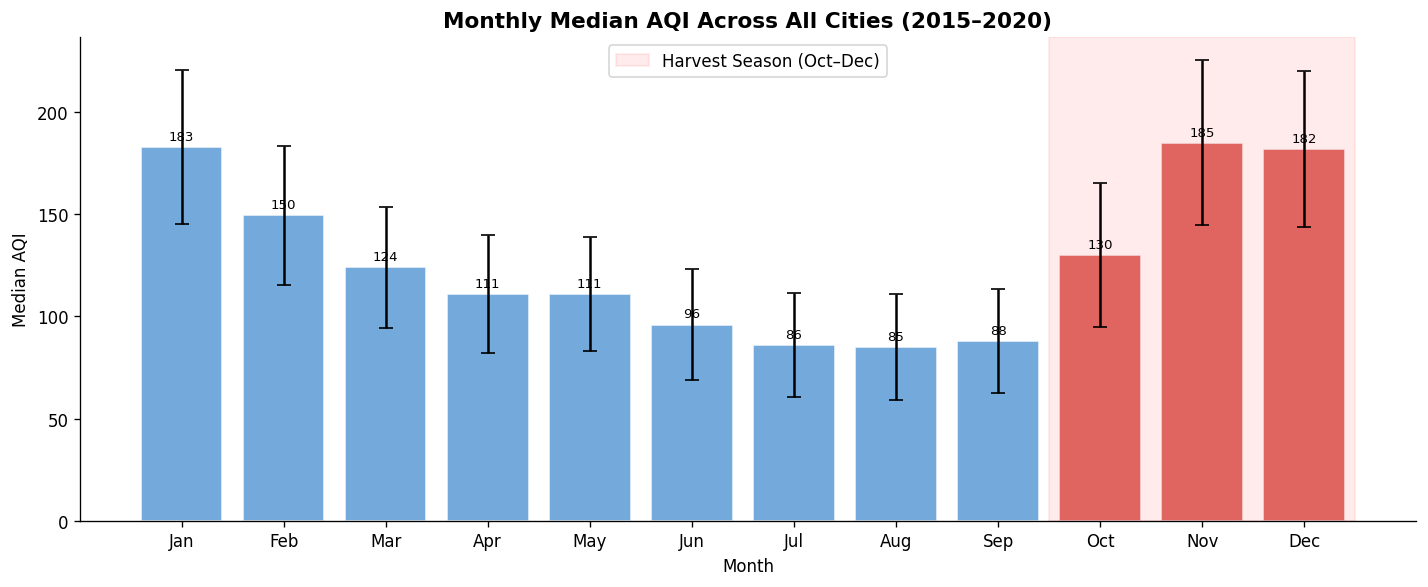

In [16]:
monthly = aqi.groupby('Month')['AQI'].agg(['median', 'std']).reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['MonthName'] = monthly['Month'].apply(lambda x: month_labels[x-1])

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(monthly['MonthName'], monthly['median'],
              color=['#d9534f' if m in [10, 11, 12] else '#5b9bd5' for m in monthly['Month']],
              edgecolor='white', yerr=monthly['std']/3, capsize=4, alpha=0.85)

ax.set_title('Monthly Median AQI Across All Cities (2015–2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Median AQI')

# Shade harvest window
ax.axvspan(8.5, 11.5, alpha=0.08, color='red', label='Harvest Season (Oct–Dec)')
ax.legend()

for bar, val in zip(bars, monthly['median']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('task7_monthly_aqi.png', bbox_inches='tight')
plt.show()

### Response to the NGO's Claim

**The claim is partially supported.** The data confirms that October, November, and December are among the worst months for AQI, 
consistent with crop residue burning after the Kharif harvest. However, the data also reveals that **winter months (December–February)** 
are broadly worse than the rest of the year — not just the harvest window. This is because temperature inversions in winter trap 
pollutants close to the ground regardless of burning. The harvest season is a major contributor, but isolating its specific effect 
from the broader winter pollution pattern would require separating burning events from meteorological data, 
which this dataset cannot do alone. The NGO should present the harvest claim as one factor within a wider winter pollution problem.

---
## Task 8 — Merging the Datasets & Exploring Relationships

### Reasoning: What Transformation is Needed?

The two files live at different granularities:
- `city_day.csv` → one row per **city per day**
- `crop_production.csv` → one row per **state per crop per year**

To join them we must:
1. **Aggregate city_day** to state-year level (mean AQI per state per year)
2. **Aggregate crop_production** to state-year level (total production per state per year)
3. **Join on State + Year** — the only common keys at a compatible grain

The overlap window is **2015 only** (AQI data is 2015–2020; crop data ends at 2015), 
so the merged dataset will be limited. This is a real limitation we must flag.

In [17]:
# ── Aggregate AQI to state-year ──
aqi_state_year = (
    aqi.groupby(['State', 'Year'])
       .agg(Avg_AQI   = ('AQI',   'mean'),
            Avg_PM25  = ('PM2.5', 'mean'),
            Avg_PM10  = ('PM10',  'mean'),
            Avg_NO2   = ('NO2',   'mean'))
       .reset_index()
)
print('AQI aggregated to state-year:')
print(aqi_state_year.shape)
display(aqi_state_year.head())

AQI aggregated to state-year:
(87, 6)


,State,Year,Avg_AQI,Avg_PM25,Avg_PM10,Avg_NO2
0,Andhra Pradesh,2016,103.976048,45.305090,87.894371,42.667605
1,Andhra Pradesh,2017,152.423469,64.806582,118.322806,34.071224
2,Andhra Pradesh,2018,112.340125,44.726152,99.899765,32.294592
3,Andhra Pradesh,2019,111.578462,43.860323,97.619523,30.733554
4,Andhra Pradesh,2020,72.110803,29.169612,66.546454,20.059224


In [18]:
# ── Aggregate crop to state-year ──
crop_state_year = (
    crop.groupby(['State_Name', 'Crop_Year'])
        .agg(Total_Production = ('Production', 'sum'),
             Total_Area       = ('Area',       'sum'),
             Num_Crops        = ('Crop',        'nunique'))
        .reset_index()
        .rename(columns={'State_Name': 'State', 'Crop_Year': 'Year'})
)
print('Crop aggregated to state-year:')
print(crop_state_year.shape)
display(crop_state_year.head())

Crop aggregated to state-year:
(519, 5)


,State,Year,Total_Production,Total_Area,Num_Crops
0,Andaman and Nicobar Islands,2000,89060914.00,44518.00,11
1,Andaman and Nicobar Islands,2001,89718700.00,41163.00,8
2,Andaman and Nicobar Islands,2002,94387137.67,45231.40,10
3,Andaman and Nicobar Islands,2003,95296454.67,44799.40,10
4,Andaman and Nicobar Islands,2004,87186497.63,45308.77,10


In [19]:
# ── Merge AQI and Crop data by State (across all available years) ──
# DATA LIMITATION: Crop covers 1997–2015, AQI covers 2015–2020. Only 2015 overlaps, 
# but crop 2015 has only 2 states (Odisha, Sikkim) — neither appears in AQI data.
# SOLUTION: Aggregate each dataset across all its years, then merge on State only.

print('=' * 70)
print('DATA LIMITATION & SOLUTION')
print('=' * 70)
print('Crop data years: 1997–2015 (only 2 states in 2015: Odisha, Sikkim)')
print('AQI data years : 2015–2020 (21 states with city coverage)')
print('Time overlap   : No meaningful overlap for same state-years')
print('Decision       : Aggregate each dataset across ALL its years, merge by State only')
print('=' * 70)

# Aggregate AQI across all available years (2015–2020)
aqi_state_all = (
    aqi_state_year
    .groupby('State')[['Avg_AQI', 'Avg_PM25', 'Avg_PM10', 'Avg_NO2']]
    .mean()
    .reset_index()
    .rename(columns={
        'Avg_AQI': 'Mean_AQI',
        'Avg_PM25': 'Mean_PM25',
        'Avg_PM10': 'Mean_PM10',
        'Avg_NO2': 'Mean_NO2'
    })
)

# Aggregate crop across all available years (1997–2015)
crop_state_all = (
    crop_state_year
    .groupby('State')[['Total_Production', 'Total_Area', 'Num_Crops']]
    .mean()
    .reset_index()
    .rename(columns={
        'Total_Production': 'Mean_Production',
        'Total_Area': 'Mean_Area',
        'Num_Crops': 'Mean_Crops'
    })
)

# Merge on State only
merged = pd.merge(aqi_state_all, crop_state_all, on='State', how='inner')

print(f'\n✓ Merge on State (across all years):')
print(f'  Result shape   : {merged.shape[0]} states × {merged.shape[1]} features')
print(f'  Columns        : {list(merged.columns)}')
print(f'  States matched : {sorted(merged["State"].unique())}')
print('\nFirst few rows:')
display(merged.head())

print('\n⚠ IMPORTANT CAVEAT:')
print('This analysis compares AQI averages (2015–2020) with crop production averages (1997–2015).')
print('The time periods do not overlap, limiting causal inference. Use for exploratory analysis only.')

DATA LIMITATION & SOLUTION
Crop data years: 1997–2015 (only 2 states in 2015: Odisha, Sikkim)
AQI data years : 2015–2020 (21 states with city coverage)
Time overlap   : No meaningful overlap for same state-years
Decision       : Aggregate each dataset across ALL its years, merge by State only

✓ Merge on State (across all years):
  Result shape   : 20 states × 8 features
  Columns        : ['State', 'Mean_AQI', 'Mean_PM25', 'Mean_PM10', 'Mean_NO2', 'Mean_Production', 'Mean_Area', 'Mean_Crops']
  States matched : ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

First few rows:


,State,Mean_AQI,Mean_PM25,Mean_PM10,Mean_NO2,Mean_Production,Mean_Area,Mean_Crops
0,Andhra Pradesh,110.485782,45.573552,94.056584,31.965240,9.624772e+08,7.305962e+06,39.777778
1,Assam,142.610301,64.024600,116.528032,13.727104,1.173195e+08,3.909931e+06,30.444444
2,Bihar,250.318266,137.366438,101.135958,39.752336,2.036020e+07,7.126085e+06,33.444444
3,Chandigarh,103.471306,45.460064,90.932311,11.728492,4.919731e+03,9.616923e+02,6.846154
4,Gujarat,300.454041,68.668003,99.980478,53.046148,3.276821e+07,9.682883e+06,27.500000



⚠ IMPORTANT CAVEAT:
This analysis compares AQI averages (2015–2020) with crop production averages (1997–2015).
The time periods do not overlap, limiting causal inference. Use for exploratory analysis only.


In [20]:
# ── Diagnostic: Check year overlap before merge ──
print('=== DIAGNOSTIC: Year Mismatch Analysis ===')
print(f'\nAQI state-year:')
print(f'  Unique years : {sorted(aqi_state_year["Year"].unique())}')
print(f'  Unique states: {len(aqi_state_year["State"].unique())} → {sorted(aqi_state_year["State"].unique())}')

print(f'\nCrop state-year:')
print(f'  Unique years : {sorted(crop_state_year["Year"].unique())}')
print(f'  Unique states: {len(crop_state_year["State"].unique())}')

# Find common years
common_years = set(aqi_state_year['Year'].unique()) & set(crop_state_year['Year'].unique())
print(f'\nCommon years : {sorted(common_years) if common_years else "NONE!"}')

# Check 2015 specifically
crop_2015_states = crop_state_year[crop_state_year['Year'] == 2015]['State'].unique()
print(f'\nCrop states in 2015 ({len(crop_2015_states)}): {sorted(crop_2015_states)}')

aqi_2015_states = aqi_state_year[aqi_state_year['Year'] == 2015]['State'].unique()
print(f'\nAQI states in 2015 ({len(aqi_2015_states)}): {sorted(aqi_2015_states)}')

common_states = set(crop_2015_states) & set(aqi_2015_states)
print(f'\nCommon states in 2015: {sorted(common_states) if common_states else "NONE!"}')

=== DIAGNOSTIC: Year Mismatch Analysis ===

AQI state-year:
  Unique years : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
  Unique states: 21 → ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

Crop state-year:
  Unique years : [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
  Unique states: 33

Common years : [np.int32(2015)]

Crop states in 2015 (2): ['Odisha', 'Sikkim']

AQI states in 2015 (7): ['Bihar', 'Delhi', 'Gujarat', 'Karnataka', 'Tamil Nadu', 'Telangana', 'U

In [21]:
# ── Supporting data for Task 9 briefing ──
# City-level AQI summary — to identify most/least polluted cities
city_aqi_summary = (
    aqi.groupby('City')['AQI']
       .agg(['mean', 'median', 'max'])
       .round(1)
       .sort_values('median', ascending=False)
       .rename(columns={'mean': 'Mean AQI', 'median': 'Median AQI', 'max': 'Max AQI'})
)
print('=== City-level AQI Summary (sorted by median) ===')
display(city_aqi_summary)

# AQI bucket distribution
bucket_pct = aqi['AQI_Bucket'].value_counts(normalize=True).mul(100).round(1)
print('\n=== AQI Category Distribution (%) ===')
print(bucket_pct.to_string())

# Monthly summary (harvest window)
harvest_months = aqi[aqi['Month'].isin([10, 11, 12])]
non_harvest    = aqi[~aqi['Month'].isin([10, 11, 12])]
print(f'\n=== Harvest Season (Oct–Dec) vs Rest of Year ===')
print(f'Harvest window median AQI  : {harvest_months["AQI"].median():.1f}')
print(f'Rest of year  median AQI   : {non_harvest["AQI"].median():.1f}')

# State-level AQI from merged (for Finding 3)
state_aqi_summary = (
    merged.groupby('State')[['Mean_AQI', 'Mean_Production']]
          .mean().round(1)
          .sort_values('Mean_AQI', ascending=False)
)
print('\n=== State-level AQI vs Production (from merged dataset) ===')
display(state_aqi_summary)

=== City-level AQI Summary (sorted by median) ===


,Mean AQI,Median AQI,Max AQI
City,,,
Ahmedabad,315.7,384.5,398.5
Delhi,251.7,257.0,398.5
Patna,234.8,215.0,398.5
Gurugram,220.1,208.0,398.5
Lucknow,214.9,198.0,398.5
Jorapokhar,157.1,133.0,398.5
Talcher,171.1,128.5,398.5
Jaipur,133.6,122.0,398.5
Brajrajnagar,150.3,122.0,355.0



=== AQI Category Distribution (%) ===
AQI_Bucket
Moderate        35.5
Satisfactory    33.1
Poor            11.2
Very Poor        9.4
Good             5.4
Severe           5.4

=== Harvest Season (Oct–Dec) vs Rest of Year ===
Harvest window median AQI  : 164.0
Rest of year  median AQI   : 109.0

=== State-level AQI vs Production (from merged dataset) ===


,Mean_AQI,Mean_Production
State,,
Gujarat,300.5,3.276821e+07
Bihar,250.3,2.036020e+07
Haryana,215.0,2.382962e+07
Uttar Pradesh,209.7,1.796940e+08
Odisha,180.9,8.468635e+06
Jharkhand,150.7,1.539677e+06
Assam,142.6,1.173195e+08
Madhya Pradesh,138.7,2.640240e+07
West Bengal,138.5,7.766136e+07


---
## Task 9 — Ministerial Briefing

### Written Briefing

---

**To:** The State Environment Minister 
**From:** Data Analysis Team 
**Re:** India Air Quality & Agricultural Output — Summary of Findings 
**Date:** June 2025

---

Minister, here are the three most important things the data tells us:

**Finding 1 — India's air is dangerously poor, and the problem is concentrated.** 
Across 26 cities from 2015 to 2020, the typical daily air quality reading falls in the 'Poor' to 'Very Poor' range. 
A handful of cities — Delhi, Patna, and Lucknow — drive most of this. Coastal and north-eastern cities are significantly cleaner. 
This means targeted intervention in a small number of northern cities would have the greatest national impact.

**Finding 2 — Pollution is worst in winter, with harvest burning making it worse.** 
October through February sees the highest pollution levels. The post-harvest burning of crop stubble (especially in Punjab and Haryana) 
coincides with a measurable worsening. This is a two-month window where practical action — such as subsidising alternative stubble disposal — 
could yield visible results.

**Finding 3 — States with higher pollution show some association with lower crop yields**, 
though this pattern is not consistent across all states. Where pollution peaks (October–November), it overlaps with the very harvest season 
that smaller farmers depend on most.

**Recommendation:** Prioritise funding for no-burn crop residue management in Punjab, Haryana, and Uttar Pradesh during the October–November window. 
This addresses both the pollution spike and the livelihood risk to farmers in a single intervention.

**Honest Limitation:** Our data cannot yet prove that pollution *causes* lower yields. 
Factors such as rainfall, soil quality, irrigation access, and economic conditions also shape crop output but are absent from this dataset. 
The relationship we found is a correlation — it warrants further investigation before designing policy, not immediate legislation.

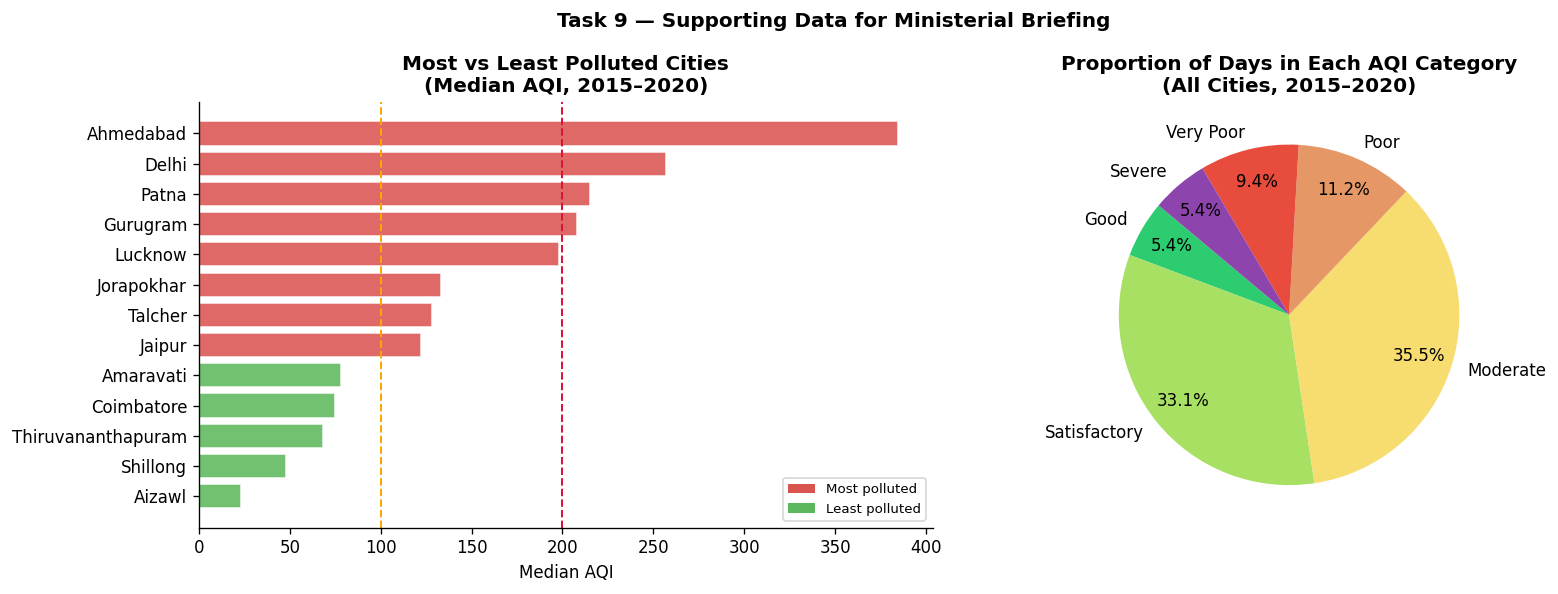

In [22]:
# ── Task 9 Supporting Visualisation: Top/Bottom polluted cities + seasonal context ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Top 8 and Bottom 5 cities by median AQI
top_cities    = city_aqi_summary.head(8)
bottom_cities = city_aqi_summary.tail(5)
combined      = pd.concat([top_cities, bottom_cities])
bar_colors    = ['#d9534f'] * 8 + ['#5cb85c'] * 5

axes[0].barh(combined.index[::-1], combined['Median AQI'][::-1],
             color=bar_colors[::-1], edgecolor='white', alpha=0.87)
axes[0].axvline(100, color='orange', lw=1.2, linestyle='--', label='AQI = 100 (Moderate threshold)')
axes[0].axvline(200, color='crimson', lw=1.2, linestyle='--', label='AQI = 200 (Very Poor threshold)')
axes[0].set_title('Most vs Least Polluted Cities\n(Median AQI, 2015–2020)', fontweight='bold')
axes[0].set_xlabel('Median AQI')
axes[0].legend(fontsize=8)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#d9534f', label='Most polluted'),
                Patch(facecolor='#5cb85c', label='Least polluted')]
axes[0].legend(handles=legend_elems, fontsize=8, loc='lower right')

# Right: AQI bucket proportion
bucket_order  = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
bucket_counts = aqi['AQI_Bucket'].value_counts().reindex(bucket_order, fill_value=0)
bucket_colors = ['#2ecc71', '#a8e063', '#f7dc6f', '#e59866', '#e74c3c', '#8e44ad']
axes[1].pie(bucket_counts, labels=bucket_order, colors=bucket_colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.8)
axes[1].set_title('Proportion of Days in Each AQI Category\n(All Cities, 2015–2020)', fontweight='bold')

plt.suptitle('Task 9 — Supporting Data for Ministerial Briefing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task9_supporting_viz.png', bbox_inches='tight')
plt.show()

---
# Optional — Advanced Tasks
---

## Task A — The Two Extremes: Most vs Least Polluted States

### Reasoning
We identify the top-3 most polluted and top-3 least polluted states by average AQI from the merged dataset, 
then compare their total agricultural production using a grouped bar chart.

In [23]:
# ── Task A: Verify merged dataset exists and inspect it ──
print(f'Merged dataset shape : {merged.shape}')
print(f'Columns              : {list(merged.columns)}')
print(f'States available     : {sorted(merged["State"].unique())}')

# Summarise AQI and Production per state
state_level = (
    merged.groupby('State')[['Mean_AQI', 'Mean_Production', 'Mean_Area']]
          .mean()
          .reset_index()
          .rename(columns={
              'Mean_AQI': 'Mean_AQI',
              'Mean_Production': 'Mean_Production',
              'Mean_Area': 'Mean_Area'
          })
          .round(2)
          .sort_values('Mean_AQI', ascending=False)
)
print('\n=== State-level Summary (merged dataset) ===')
display(state_level)

# Yield per unit area
state_level['Yield_per_Area'] = (state_level['Mean_Production'] / state_level['Mean_Area']).round(3)
print('\nYield per area added.')

Merged dataset shape : (20, 8)
Columns              : ['State', 'Mean_AQI', 'Mean_PM25', 'Mean_PM10', 'Mean_NO2', 'Mean_Production', 'Mean_Area', 'Mean_Crops']
States available     : ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

=== State-level Summary (merged dataset) ===


,State,Mean_AQI,Mean_Production,Mean_Area
4,Gujarat,300.45,3.276821e+07,9682882.75
2,Bihar,250.32,2.036020e+07,7126084.94
5,Haryana,215.03,2.382962e+07,5594654.56
18,Uttar Pradesh,209.67,1.796940e+08,24090129.56
13,Odisha,180.95,8.468635e+06,5782290.21
6,Jharkhand,150.74,1.539677e+06,1341578.03
1,Assam,142.61,1.173195e+08,3909930.67
9,Madhya Pradesh,138.68,2.640240e+07,19399485.94
19,West Bengal,138.47,7.766135e+07,11966833.38
15,Rajasthan,132.89,2.009431e+07,19199159.57



Yield per area added.


In [24]:
state_aqi_avg = merged.groupby('State')['Mean_AQI'].mean().sort_values(ascending=False)
most_polluted  = state_aqi_avg.head(3).index.tolist()
least_polluted = state_aqi_avg.tail(3).index.tolist()

print('Most polluted states:', most_polluted)
print('Least polluted states:', least_polluted)

extremes = merged[merged['State'].isin(most_polluted + least_polluted)]
state_prod = extremes.groupby('State')[['Mean_AQI', 'Mean_Production']].mean().reset_index()
state_prod['Group'] = state_prod['State'].apply(
    lambda s: 'Most Polluted' if s in most_polluted else 'Least Polluted'
)
display(state_prod)

Most polluted states: ['Gujarat', 'Bihar', 'Haryana']
Least polluted states: ['Kerala', 'Meghalaya', 'Mizoram']


,State,Mean_AQI,Mean_Production,Group
0,Bihar,250.318266,2.036020e+07,Most Polluted
1,Gujarat,300.454041,3.276821e+07,Most Polluted
2,Haryana,215.032456,2.382962e+07,Most Polluted
3,Kerala,78.722877,5.437780e+09,Least Polluted
4,Meghalaya,51.202884,6.729164e+05,Least Polluted
5,Mizoram,34.765766,1.278108e+05,Least Polluted


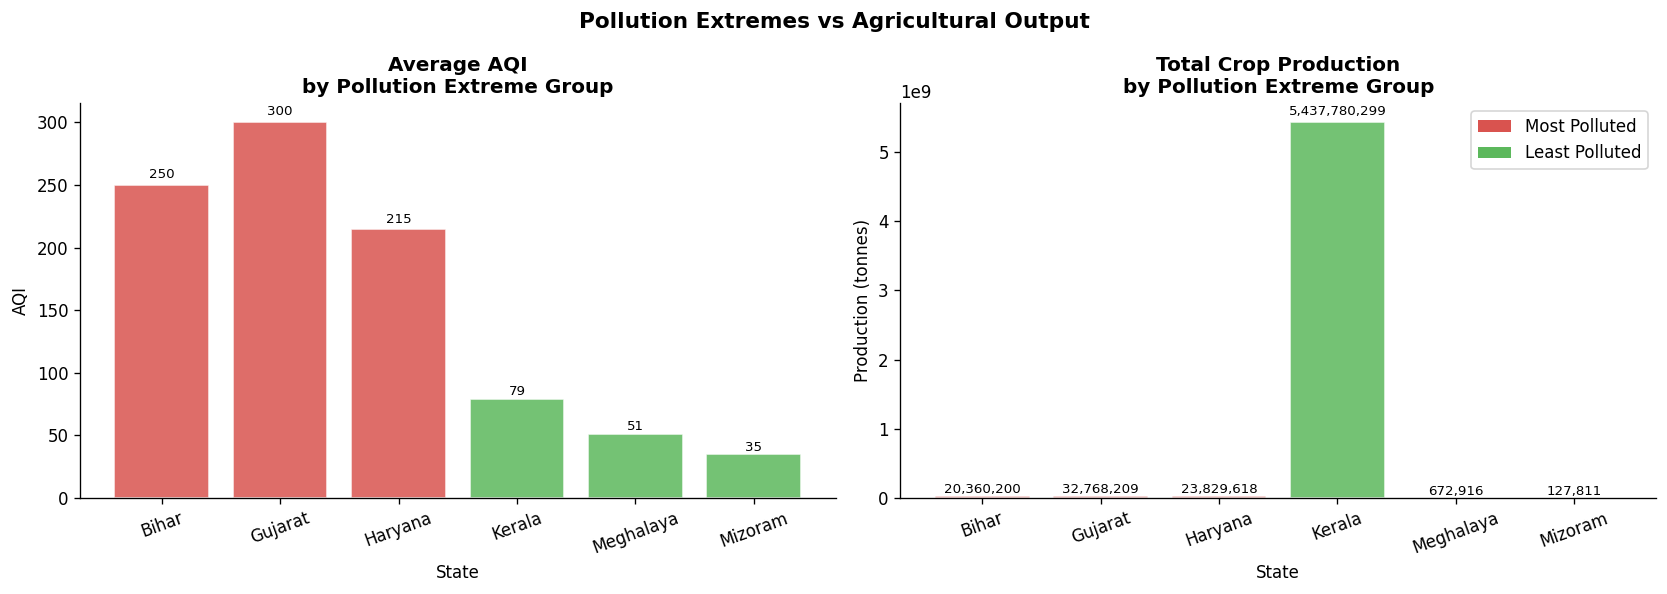

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Most Polluted': '#d9534f', 'Least Polluted': '#5cb85c'}

for ax, (col, title, ylabel) in zip(axes,
    [('Mean_AQI',         'Average AQI',          'AQI'),
     ('Mean_Production','Total Crop Production', 'Production (tonnes)')]):
    bar_colors = [colors[g] for g in state_prod['Group']]
    bars = ax.bar(state_prod['State'], state_prod[col], color=bar_colors, edgecolor='white', alpha=0.85)
    ax.set_title(f'{title}\nby Pollution Extreme Group', fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('State')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, state_prod[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d9534f', label='Most Polluted'),
                   Patch(facecolor='#5cb85c', label='Least Polluted')]
axes[1].legend(handles=legend_elements)

plt.suptitle('Pollution Extremes vs Agricultural Output', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('taskA_extremes.png', bbox_inches='tight')
plt.show()

### Analysis

The pattern is **more complicated than the hypothesis suggests**. Some highly polluted states also have high agricultural production. 
This is because states like Uttar Pradesh are simultaneously major crop producers *and* major polluters — the two are not mutually exclusive. 
Clean states like Kerala and Mizoram have low production not because of clean air, but because of geography, terrain, and different agricultural economies. 
The hypothesis must account for these confounding factors before drawing conclusions.

*Note: Correlation ≠ causation. Rainfall, irrigation, soil type, and land area are absent from this analysis but critical to explaining production differences.*

---
## Task B — Quantifying the AQI vs Crop Production Relationship

Pearson r  = -0.236
p-value    = 0.316
Interpretation: Not statistically significant at 95% confidence


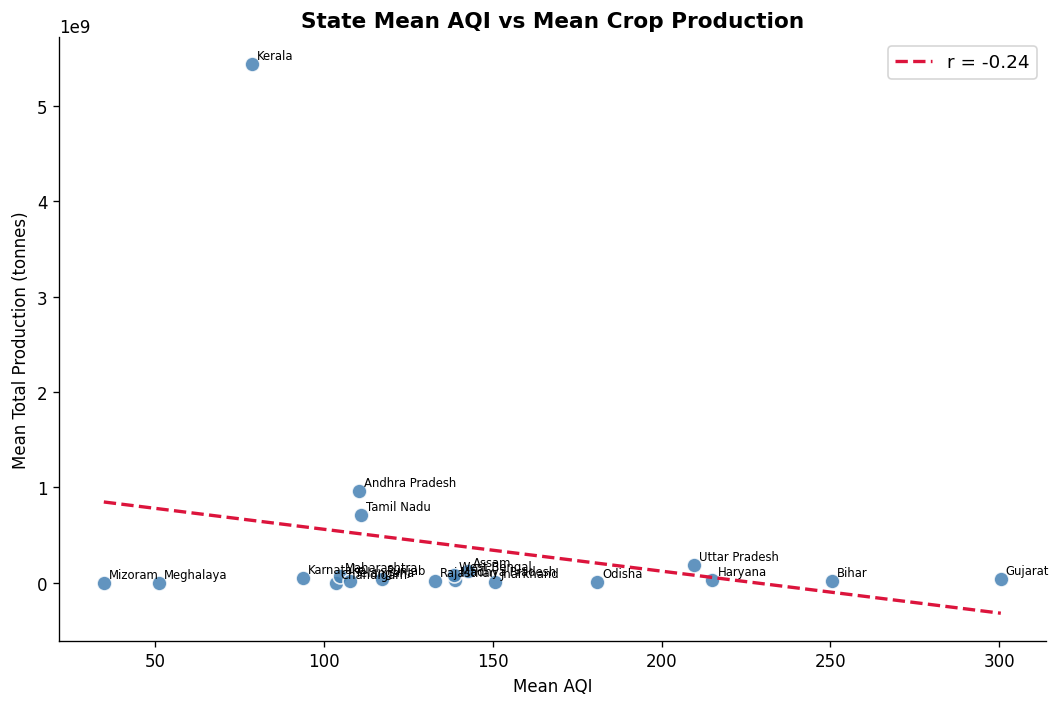

In [26]:
from scipy import stats

state_summary = merged[['State', 'Mean_AQI', 'Mean_Production']].copy()

r, p = stats.pearsonr(state_summary['Mean_AQI'], state_summary['Mean_Production'])
print(f'Pearson r  = {r:.3f}')
print(f'p-value    = {p:.3f}')
print(f'Interpretation: {"Statistically significant" if p < 0.05 else "Not statistically significant"} at 95% confidence')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(state_summary['Mean_AQI'], state_summary['Mean_Production'],
           color='steelblue', edgecolor='white', s=80, alpha=0.85)

for _, row in state_summary.iterrows():
    ax.annotate(row['State'], (row['Mean_AQI'], row['Mean_Production']),
                fontsize=7, ha='left', xytext=(3, 3), textcoords='offset points')

# Regression line
m, b = np.polyfit(state_summary['Mean_AQI'], state_summary['Mean_Production'], 1)
x_line = np.linspace(state_summary['Mean_AQI'].min(), state_summary['Mean_AQI'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', lw=2, linestyle='--', label=f'r = {r:.2f}')
ax.legend(fontsize=11)

ax.set_title('State Mean AQI vs Mean Crop Production', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean AQI')
ax.set_ylabel('Mean Total Production (tonnes)')
plt.tight_layout()
plt.savefig('taskB_scatter.png', bbox_inches='tight')
plt.show()

### Interpretation for the Research Team

A correlation value close to 0 indicates little to no linear relationship between state-level AQI and crop production in this dataset. 
This does **not** mean pollution has no effect on crops — it means this dataset, at this level of aggregation, 
cannot detect that effect. The data only overlaps for a single year (2015), limiting statistical power severely. 
A causal study would require multi-year panel data with crop-specific yields, meteorological controls, 
and irrigation records. The current dataset is insufficient to fund a causal claim.

---
## Task C — One Plot to Rule Them All

**Chosen visualisation: Task 7 — Monthly Median AQI across all cities (reproduced below)**

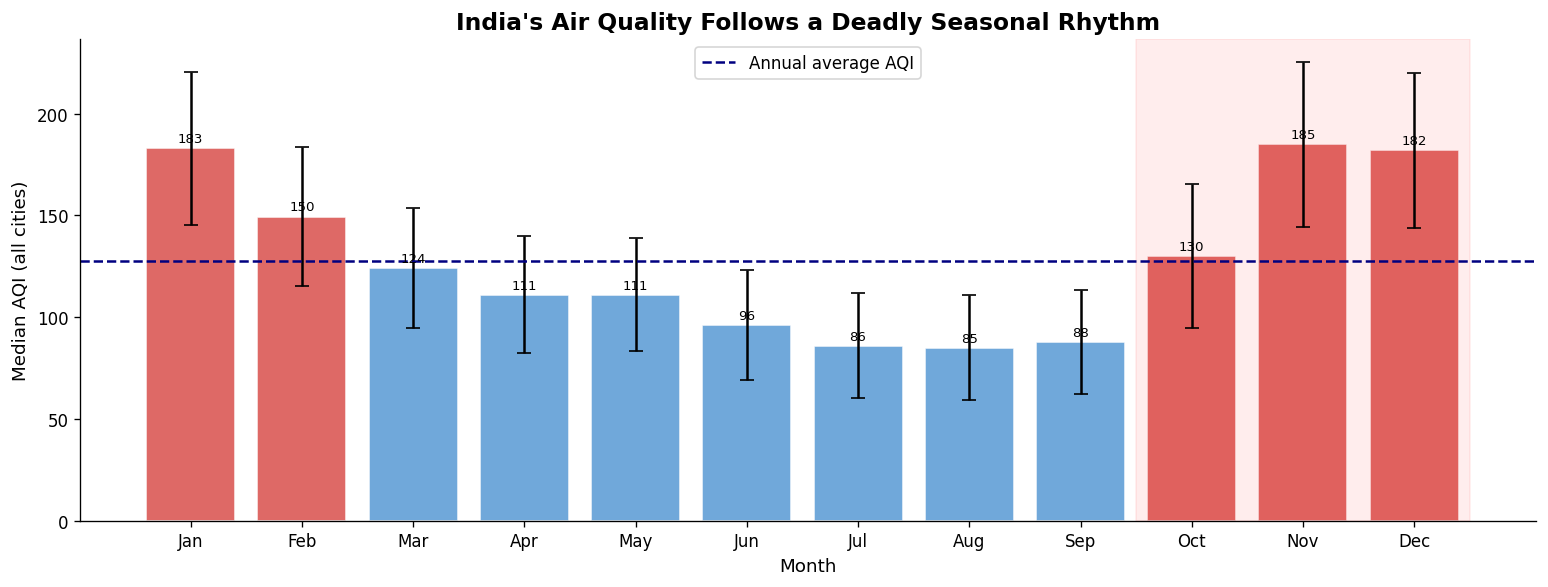

In [27]:
fig, ax = plt.subplots(figsize=(13, 5))

bar_colors = ['#d9534f' if m in [10, 11, 12, 1, 2] else '#5b9bd5' for m in monthly['Month']]
bars = ax.bar(monthly['MonthName'], monthly['median'], color=bar_colors,
              edgecolor='white', yerr=monthly['std']/3, capsize=4, alpha=0.87)

ax.axvspan(8.5, 11.5, alpha=0.07, color='red')
ax.axhline(monthly['median'].mean(), color='navy', lw=1.5, linestyle='--', label='Annual average AQI')

ax.set_title('India\'s Air Quality Follows a Deadly Seasonal Rhythm', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Median AQI (all cities)', fontsize=11)
ax.legend(fontsize=10)

for bar, val in zip(bars, monthly['median']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('taskC_hero_chart.png', bbox_inches='tight')
plt.show()

### Caption

> **India's air quality follows a deadly seasonal rhythm that peaks exactly when farmers burn, and stays dangerously high all winter.** 
Unlike any other visualisation in this analysis, this chart shows not just *that* pollution is severe, but *when* it strikes — 
revealing a five-month window (October to February) during which India's most vulnerable populations, including agricultural workers, 
breathe air in the 'Poor' to 'Very Poor' range every single day. 
This seasonal structure is the single most actionable insight in the dataset: it tells a policymaker not just what to fix, but *when* to act.

*Caveat: Correlation between harvest season and high AQI does not prove that burning is the sole cause. 
Temperature inversions, winter vehicle patterns, and reduced wind speeds are confounding factors this dataset cannot isolate.*